In this notebook, we train versions of the SteinHierarchical Model with different counts of steinparticles to see if they make a difference

In [1]:
%load_ext autoreload
%autoreload 2
from utils import *
import time
from jax.example_libraries import stax
from numpyro import optim
from CustomModules.architectures import *
from CustomModules.normalizing_flow import normalizing_flow
from sklearn.datasets import fetch_openml
import sklearn
from sklearn.metrics import mean_squared_error
import pandas as pd

import pickle
import os

import jax
import jax.numpy as jnp

KeyboardInterrupt: 

# Jax psuedo random keys


In [ ]:

# For reproducibility, we define a deterministic hashing function for our random keys
# Each unique string will correspond to a unique random independent key, but the same string will always yield the same key.
# Here I make sure to start at a different key from Toy Data experiments
key_for = make_key_for(jax.random.key(2))

E0531 14:25:08.212850   49353 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0531 14:25:08.226187   49213 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


# Data

In [ ]:

mnist = fetch_openml("mnist_784")
mnist_data = np.array(mnist.data) / 255.0
mnist_targets = np.array(mnist.target).astype(int)

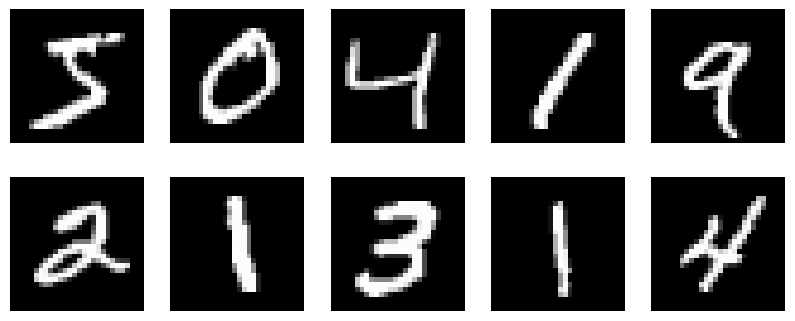

In [ ]:
plot_images(mnist_data[:10], shape=(28, 28))

In [ ]:
diff = mnist_data.max() - mnist_data.min()

# squish the data to be between 0 and 1
mnist_data = (mnist_data - mnist_data.min()) / diff if mnist_data.max() != mnist_data.min() else mnist_data

X_train_p, X_test_p, y_train, y_test = sklearn.model_selection.train_test_split(mnist_data, mnist_targets, test_size=0.2, random_state=42)



# Binarize by sampling from it as a distrubution

X_train = np.random.binomial(1, X_train_p)
X_test = np.random.binomial(1, X_test_p)


batch_size = 128

train_loader = [X_train[i:i+batch_size] for i in range(0, len(X_train), batch_size)]
test_loader = [X_test[i:i+batch_size] for i in range(0, len(X_test), batch_size)]

train_size = len(X_train)
test_size = len(X_test)

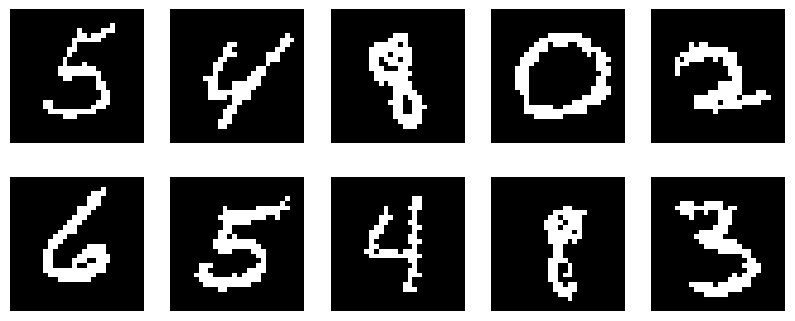

In [ ]:
plot_images(X_train[:10], shape=(28, 28))

# Define Model Architectures


## Networks


Here i define the networks. Some stabilizing has been added like clipping, variance floors and predetermined start-variances by shift x

In [ ]:
def decoder(hidden_dim, out_dim):
    return stax.serial(
        stax.Dense(hidden_dim),
        stax.LeakyRelu,
        stax.Dense(out_dim),
    )

def f_shared(hidden_dim, f_dim):
    return stax.serial(
        stax.Dense(hidden_dim),
        stax.LeakyRelu,
        stax.Dense(hidden_dim),
        stax.LeakyRelu,
        stax.Dense(f_dim),
        stax.elementwise(lambda x: jnp.clip(x, -10.0, 10.0))
    )

def g(z_dim, variance_floor=0.1):
    SafeSoftplus = stax.elementwise(lambda x: jnp.clip(stax.softplus(x-3.0), min=0.0, max=20.0) + variance_floor)
    return stax.serial(
        stax.FanOut(2),
        stax.parallel(
            stax.serial(stax.Dense(z_dim), stax.elementwise(lambda x: jnp.clip(x, -10.0, 10.0))),
            stax.serial(stax.Dense(z_dim), SafeSoftplus),
        )
    )

def h(hidden_dim, h_dim):
    return stax.serial(
        stax.Dense(hidden_dim),
        stax.LeakyRelu,
        stax.Dense(h_dim),
    )

## Hyperparameters


In [ ]:

out_dim = X_train.shape[1]
hidden_dim =128
z_dim = 50
m_dim = 5
h_dim = 20


lr=5e-3

def lr_scheduler(lr_start=5e-3, decay_rate=0.9, decay_steps=300, floor=1e-5):
    def schedule(step):
        return lr_start * (decay_rate ** (step // decay_steps)) + floor
    return schedule

decoder_args = {"hidden_dim": hidden_dim, "out_dim": out_dim}
f_args = {"hidden_dim": z_dim, "f_dim": z_dim}
g_args = {"z_dim": z_dim, "variance_floor": 0.05}
h_args = {"hidden_dim": h_dim, "h_dim": z_dim}
flow_args = {"input_dim": m_dim, "hidden_dims": [m_dim], "steps": 0, "inv": True} # steps: 0 means flow is deactivated
hierarchical_layers = 2 # for the hierarchical model
num_elbo_particles = 10
bandwidth_scaler=0.03
stein_particles_counts = [1, 3, 5, 10]

num_epochs = 60
annealing_epochs = 15

steps = len(X_train)/batch_size * num_epochs
lr_scheduler_fn = lr_scheduler(lr, decay_rate=0.9, decay_steps=steps/30, floor=1e-5)
adam = optim.ClippedAdam(lr_scheduler_fn, clip_norm=10) # clipping for stability

Show lr_schedule

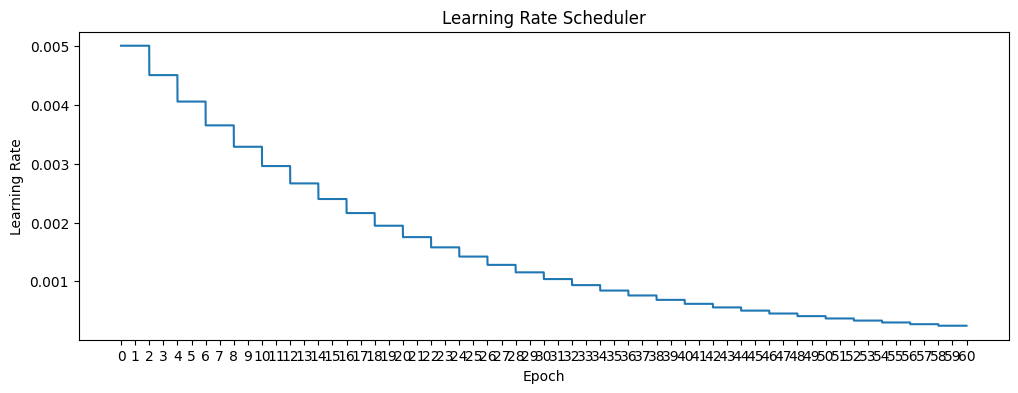

In [ ]:
lrs = [lr_scheduler_fn(step) for step in range(int(steps))]
plt.figure(figsize=(12, 4))
plt.plot(lrs)

plt.title("Learning Rate Scheduler")

plt.xticks(np.linspace(0, steps, num_epochs+1), [f"{i}" for i in range(num_epochs+1)])
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.show()


# Training

In [ ]:
# Checkpoint names:
checkpoints_dir = "checkpoints_mnist_diff"
if not os.path.exists(checkpoints_dir):
    os.makedirs(checkpoints_dir)
hier_models = f"{checkpoints_dir}/mnist_diff_hier_models.pkl"



If checkpoint already exists, then just load it, otherwise train. This ensures no wasted time

In [ ]:
trained_models = []


if os.path.exists(hier_models):
    with open(hier_models, "rb") as f:
        trained_models = pickle.load(f)
    print("Loaded Stein Hierarchical VAE from checkpoint.")
else:
    for num_stein_particles in stein_particles_counts:
        start_time = time.time()
        stein_hierarchical_vae = SteinHierarchicalVAE(decoder, decoder_args, f_shared, f_args, h, h_args, g, g_args, g, g_args, hierarchical_layers, z_dim, m_dim, normalizing_flow, flow_args, model_mode="b")
        stein_hierarchical_vae_norms = stein_hierarchical_vae.train(train_loader, train_size, adam, num_epochs, key_for("stein_hierarchical_vae_training"), 
                                                                    num_stein_particles, num_elbo_particles=num_elbo_particles,
                                                                    annealing_epochs=annealing_epochs, 
                                                                    annealed_sites=[f"z{i}" for i in range(hierarchical_layers)],
                                                                    bandwidth_scaler = bandwidth_scaler)
        end_time = time.time()
        trained_models.append((num_stein_particles, stein_hierarchical_vae, end_time - start_time, stein_hierarchical_vae_norms))
    with open(hier_models, "wb") as f:
        pickle.dump(trained_models, f)
    print(f"Trained and saved Stein Hierarchical VAES with particles: {num_stein_particles}.")


Epoch 59, Loss: 51279.23: 100%|██████████| 60/60 [03:49<00:00,  3.83s/it]


Ran with 26280 batches


Epoch 59, Loss: 51570.75: 100%|██████████| 60/60 [04:37<00:00,  4.63s/it]


Ran with 26280 batches


Epoch 59, Loss: 51514.52: 100%|██████████| 60/60 [05:58<00:00,  5.98s/it]


Ran with 26280 batches


Epoch 59, Loss: 51099.30: 100%|██████████| 60/60 [13:00<00:00, 13.00s/it]


Ran with 26280 batches
Trained and saved Stein Hierarchical VAES with particles: 10.


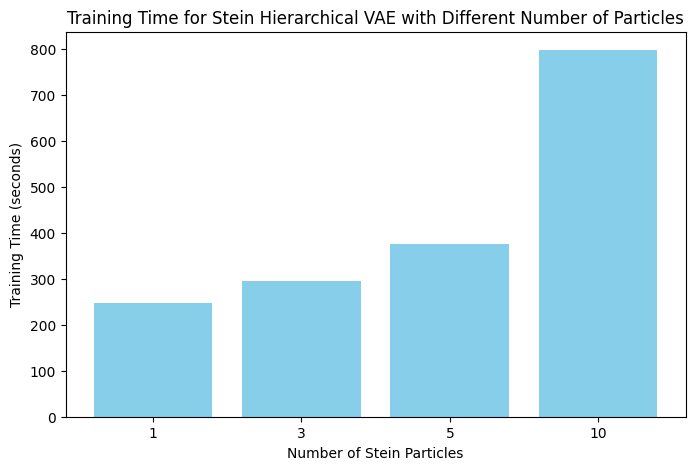

In [ ]:
# plot training times:
training_times = [model[2] for model in trained_models]
plt.figure(figsize=(8, 5))
plt.bar([str(model[0]) for model in trained_models], training_times, color='skyblue')
plt.xlabel('Number of Stein Particles')
plt.ylabel('Training Time (seconds)')
plt.title('Training Time for Stein Hierarchical VAE with Different Number of Particles')
plt.show()

# Results

In [ ]:

results = []

for d in trained_models:
    stein_hierarchical_vae = d[1]


    encoded_stein_hierarchical = stein_hierarchical_vae.encode_batch(X_test, key_for("stein_hierarchical_vae_encoding"))
    reconstructed_stein_hierarchical = np.array(jax.nn.sigmoid(stein_hierarchical_vae.decode_latent(encoded_stein_hierarchical, key_for("stein_hierarchical_vae_decoding"), size_site="z0")["x"]))

    samples_stein_hierarchical_all = stein_hierarchical_vae.sample(key_for("qual_stein_hierarchical_vae_sampling"), 10000)

    samples_stein_hierarchical = np.array(jax.nn.sigmoid(samples_stein_hierarchical_all["x"]))

    # save
    results.append((d[0], encoded_stein_hierarchical, reconstructed_stein_hierarchical, samples_stein_hierarchical))




## Quantitative Results

### Reconstructions (MSE)

In [ ]:
mse_list = []
for d in results:
    mse = mean_squared_error(X_test, d[2])
    mse_list.append(mse)

stats = pd.DataFrame({
    "Model": [f"Stein Hierarchical VAE ({num_particles} particles)" for num_particles, _, _, _ in results],
    "MSE": mse_list
})



### Samples (FID and LL)

#### LL
We use the RenyiELBO with alpha = 0. This corresponds to the IWAE objective which is an estimate of the true Log prob of the sample densities.

In [ ]:
iwae_list = []

for d in trained_models:
    stein_hierarchical_vae = d[1]
    iwae_stein_hierarchical = stein_hierarchical_vae.evaluate_iwae(
        dataloader=test_loader,
        size=test_size,
        rng_key=key_for("stein_hierarchical_vae_evaluation"),
        num_particles=5000,
    )["avg_iwae"]
    iwae_list.append(iwae_stein_hierarchical)


# add to stats
stats["IWAE"] = iwae_list


In [ ]:
stats

,Model,MSE,IWAE
0,Stein Hierarchical VAE (1 particles),0.036710,-107.17109
1,Stein Hierarchical VAE (3 particles),0.036914,-107.53556
2,Stein Hierarchical VAE (5 particles),0.036378,-107.22312
3,Stein Hierarchical VAE (10 particles),0.036594,-106.973305


#### FID

In [ ]:
fid_path = f"{checkpoints_dir}/mnist_diff_fid_list.pkl"
if os.path.exists(fid_path):
    with open(fid_path, "rb") as f:
        fid_list = pickle.load(f)
    print("Loaded FID scores from checkpoint.")
else:
    fid_list = []
    fid_calc = FIDCalculator()
    for d in results:
        fid = fid_calc.calculate_fid(torch.tensor(X_test_p), torch.tensor(d[3]))
        fid_list.append(fid)
    print("Calculated FID scores and saved to checkpoint.")

Loaded FID scores from checkpoint.


In [ ]:
# add to stats
stats["FID"] = fid_list


In [ ]:
stats

,Model,MSE,IWAE,FID
0,Stein Hierarchical VAE (1 particles),0.036710,-107.17109,0.120772
1,Stein Hierarchical VAE (3 particles),0.036914,-107.53556,0.127782
2,Stein Hierarchical VAE (5 particles),0.036378,-107.22312,0.128812
3,Stein Hierarchical VAE (10 particles),0.036594,-106.973305,0.128190
